In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

VARIANT = 3
np.random.seed(VARIANT)

**1**

In [2]:
# 1. Генерація часової осі (30 днів)
days = np.arange(1, 31)

# 2. Визначення вихідних днів (умовно кожен 6-й та 7-й день тижня: субота та неділя)
weekend = np.isin(days % 7, [6, 0])

# 3. Генерація температури: середня 6°C, відхилення в межах ±3°C
temperature = np.round(6 + np.random.uniform(-3, 3, size=30), 1)

# 4. Генерація продажів: базові 55 шт., підвищення на вихідних (15-25%), випадкові коливання
# Для Одеси (холодні напої чи кава) додаємо легку варіацію та вихідний буст
base_sales = 55
weekend_boost = np.random.uniform(0.15, 0.25, size=30) * base_sales
noise = np.random.normal(0, 4, size=30)

sales = np.round(base_sales + (weekend * weekend_boost) + noise).astype(int)

# Створення DataFrame
df = pd.DataFrame({
    "день": days,
    "вихідний": weekend,
    "температура": temperature,
    "продажі": sales
})

print(df.head())

   день  вихідний  температура  продажі
0     1     False          6.3       61
1     2     False          7.2       51
2     3     False          4.7       58
3     4     False          6.1       48
4     5     False          8.4       53


**2**

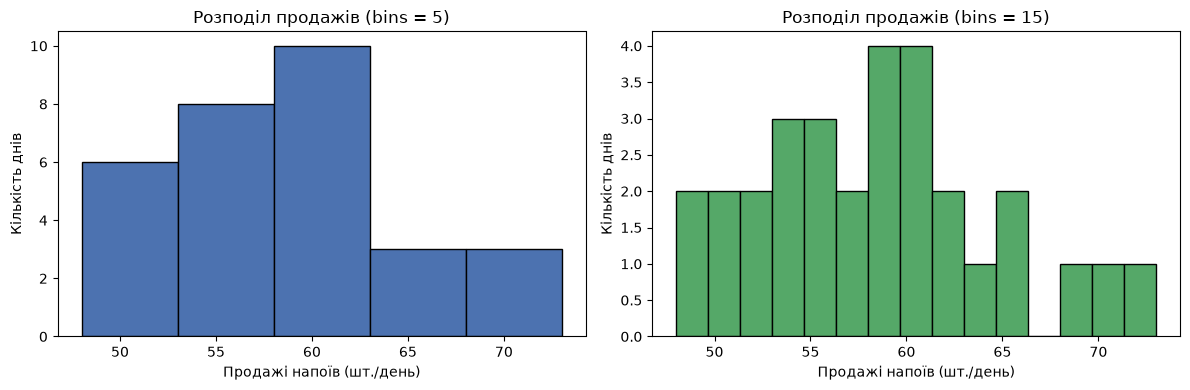

In [3]:
# Гістограма з bins=5 та bins=15 для порівняння
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Варіант A: bins=5
ax1.hist(df["продажі"], bins=5, edgecolor="black", color="#4C72B0")
ax1.set_xlabel("Продажі напоїв (шт./день)")
ax1.set_ylabel("Кількість днів")
ax1.set_title("Розподіл продажів (bins = 5)")

# Варіант B: bins=15
ax2.hist(df["продажі"], bins=15, edgecolor="black", color="#55A868")
ax2.set_xlabel("Продажі напоїв (шт./день)")
ax2.set_ylabel("Кількість днів")
ax2.set_title("Розподіл продажів (bins = 15)")

plt.tight_layout()
plt.show()

**3**

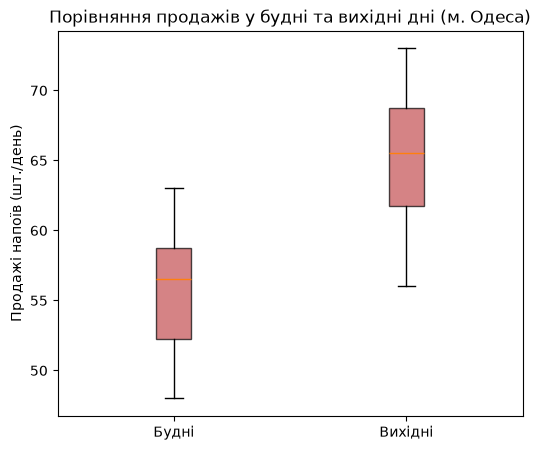

In [6]:
fig, ax = plt.subplots(figsize=(6, 5))

groups = [
    df.loc[~df["вихідний"], "продажі"],
    df.loc[df["вихідний"], "продажі"]
]

ax.boxplot(
    groups,
    tick_labels=["Будні", "Вихідні"],
    patch_artist=True,
    boxprops=dict(facecolor="#C44E52", alpha=0.7)
)

ax.set_ylabel("Продажі напоїв (шт./день)")
ax.set_title("Порівняння продажів у будні та вихідні дні (м. Одеса)")

plt.show()

**4**

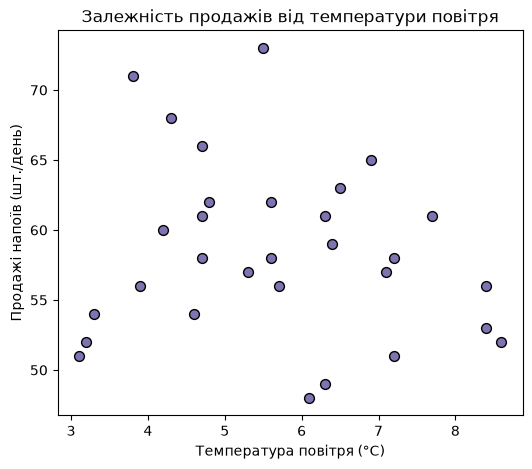

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))

ax.scatter(df["температура"], df["продажі"], color="#8172B2", edgecolor="black", s=50)

ax.set_xlabel("Температура повітря (°C)")
ax.set_ylabel("Продажі напоїв (шт./день)")
ax.set_title("Залежність продажів від температури повітря")

plt.show()

**5**

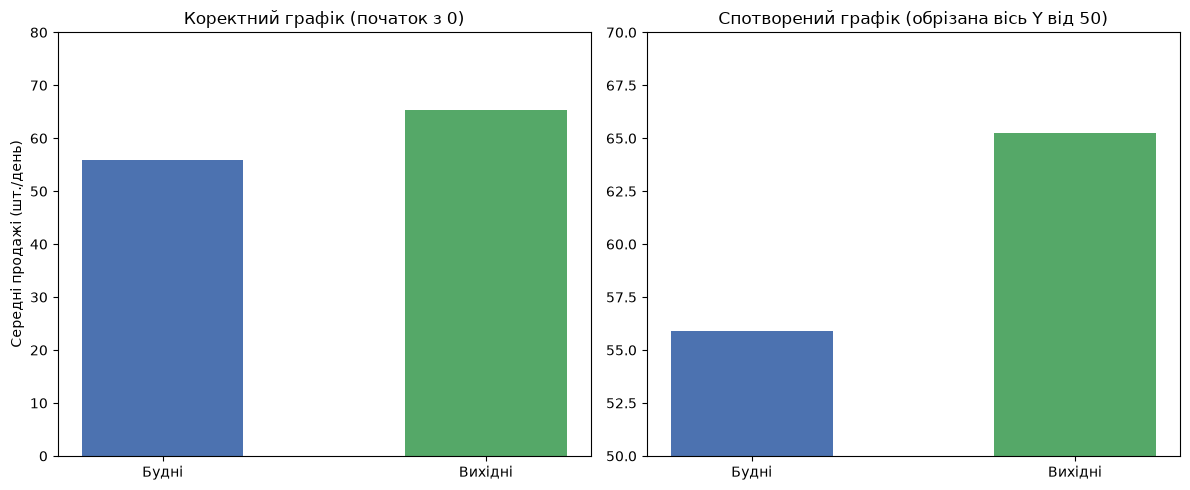

In [8]:
# Обчислення середніх продажів
mean_weekday = df.loc[~df["вихідний"], "продажі"].mean()
mean_weekend = df.loc[df["вихідний"], "продажі"].mean()

categories = ["Будні", "Вихідні"]
values = [mean_weekday, mean_weekend]

fig, (ax_correct, ax_distorted) = plt.subplots(1, 2, figsize=(12, 5))

# 1. Коректна версія (вісь Y починається з 0)
ax_correct.bar(categories, values, color=["#4C72B0", "#55A868"], width=0.5)
ax_correct.set_ylabel("Середні продажі (шт./день)")
ax_correct.set_ylim(0, 80)
ax_correct.set_title("Коректний графік (початок з 0)")

# 2. Спотворена версія (обрізана вісь Y)
ax_distorted.bar(categories, values, color=["#4C72B0", "#55A868"], width=0.5)
ax_distorted.set_ylim(50, 70)  # Штучно обрізана вісь Y
ax_distorted.set_title("Спотворений графік (обрізана вісь Y від 50)")

plt.tight_layout()
plt.show()

### Контрольні питання (Письмові відповіді)

1. **Чому обрізана вісь Y на стовпчиковій діаграмі перебільшує різницю між категоріями, хоча підписані числа лишаються правильними?**
* **Відповідь:** Стовпчикова діаграма кодує дані за допомогою *висоти (або площі)* геометричних фігур відносно базису (нуля). Коли вісь Y обрізається і починається не з $0$, візуальне співвідношення висот стовпчиків перестає відповідати дійсному співвідношенню значень. Очі аналізують геометрію швидше, ніж мозок зчитує та порівнює числа на осі, тому зорове сприйняття отримує викривлений сигнал про масштаб різниці.


2. **Приклад, коли лінійний графік є методологічною помилкою для категоріальних даних, та пояснення:**
* **Відповідь:** Якщо на осі X розмістити неупорядковані категоріальні дані (наприклад, типи напоїв: *«Кава», «Чай», «Лимонад», «Мохіто»*) і з'єднати їх точки лінією — це буде грубою помилкою. Лінія за визначенням сигналізує про **неперервність** або **тренд** між сусідніми точками (інтервальна шкала або шкала відношень, як-от час або температура). На категоріальній шкалі (номінальній) між «Чай» і «Лимонад» немає проміжних значень або математичної неперервності, тому лінія вигадує неіснуючий зв'язок.


3. **Чому підписи осей, одиниці вимірювання і заголовок — частина твердження, а не «оздоблення»?**
* **Відповідь:** Без контексту (що саме вимірюється і в яких одиницях) будь-який графік є лише набором беззмістовних геометричних фігур. Заголовок формулює головну гіпотезу або тему, підписи осей задають семантичне поле, а одиниці вимірювання ($^\circ\text{C}$, $\text{шт./день}$) визначають масштаб та сутність метрик. Графік робить контекстуальне твердження про реальний світ, і без текстового супроводу це твердження втрачає логічне та методологічне значення.


4. **Що таке chartjunk і чому він шкодить сприйняттю?**
* **Відповідь:** **Chartjunk** (графічне сміття — term by Edward Tufte) — це будь-які візуальні елементи на діаграмі, які не несуть корисної інформації про дані: 3D-ефекти, псевдооб'ємні стовпчики, зайва градієнтна заливка, декоративні фонові текстури, занадто яскраві сітки. Вони шкодять, оскільки створюють зоровий шум, відволікають увагу від аналізу самих даних, а у випадку 3D-ефектів — ще й спотворюють пропорції фігур (через перспективу верхня або передня грань здається більшою ніж є).